# Detección de contornos

En este cuaderno vas a estudiar cómo una región binaria se convierte en un borde que OpenCV puede recorrer y dibujar. Primero vamos a usar formas simples y después vamos a transferir la idea a una imagen real.


## Objetivo

Entender el pasaje máscara -> contorno y reconocer por qué la calidad de la máscara condiciona completamente el resultado final.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- construir una máscara binaria controlada;
- usar `cv2.findContours()` para recuperar bordes;
- filtrar contornos por área;
- transferir el procedimiento a una imagen real segmentada por color.

## Relación con la secuencia

Este cuaderno prepara el terreno para medir propiedades geométricas. Antes de hablar de área, perímetro o centroides, conviene entender de dónde sale exactamente el contorno.


## Módulos que vamos a usar

- `cv2`: para construir máscaras, encontrar contornos y dibujarlos.
- `numpy`: para crear imágenes binarias simples.
- `matplotlib.pyplot`: para visualizar cada etapa.
- `pathlib.Path`: para abrir la imagen real de transferencia.


In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt


## 1. Empezar con una máscara simple

Cuando el objetivo es entender cómo funciona `findContours`, conviene empezar con una imagen binaria controlada. Así el foco queda en el mecanismo y no en errores previos de segmentación.


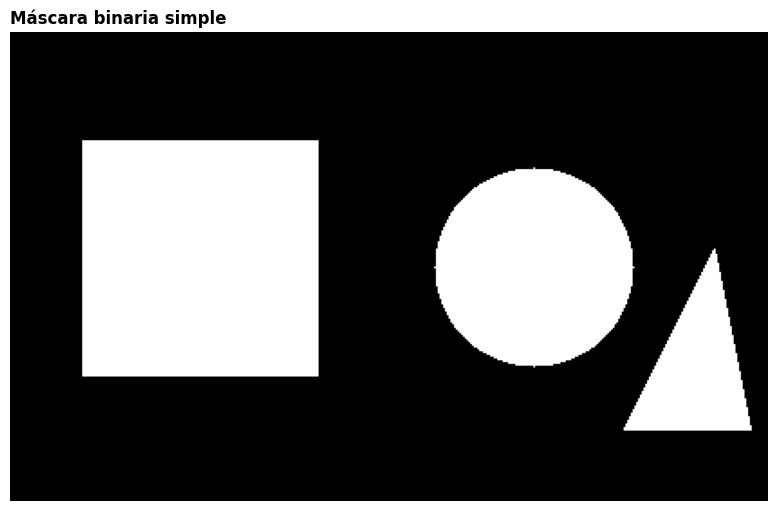

In [2]:
mascara_simple = np.zeros((260, 420), dtype=np.uint8)
cv2.rectangle(mascara_simple, (40, 60), (170, 190), 255, -1)
cv2.circle(mascara_simple, (290, 130), 55, 255, -1)
puntos_triangulo = np.array([[340, 220], [390, 120], [410, 220]], dtype=np.int32)
cv2.fillPoly(mascara_simple, [puntos_triangulo], 255)

plt.figure(figsize=(8, 5), constrained_layout=True)
plt.imshow(mascara_simple, cmap="gray")
plt.title("Máscara binaria simple", fontweight="bold", loc="left")
plt.axis("off")
plt.show()


## 2. Encontrar y dibujar contornos

`cv2.findContours()` no devuelve una imagen lista. Devuelve una lista de curvas. Después nosotros decidimos cómo mostrarlas.


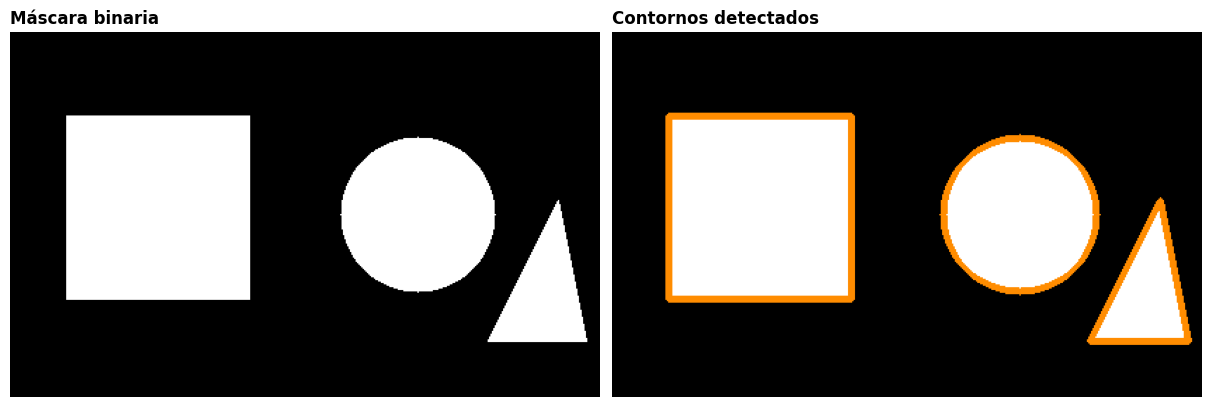

Cantidad de contornos detectados: 3


In [3]:
contornos_simples, _ = cv2.findContours(mascara_simple.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

imagen_contornos_simple = cv2.cvtColor(mascara_simple, cv2.COLOR_GRAY2RGB)
cv2.drawContours(imagen_contornos_simple, contornos_simples, -1, (255, 140, 0), 3)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
ejes[0].imshow(mascara_simple, cmap="gray")
ejes[0].set_title("Máscara binaria", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(imagen_contornos_simple)
ejes[1].set_title("Contornos detectados", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()

print(f"Cantidad de contornos detectados: {len(contornos_simples)}")


En este ejemplo la relación entre máscara y contorno es directa. Eso ayuda a entender que el contorno no “descubre” el objeto por sí solo: sigue el borde de lo que la máscara ya definió como región blanca.


## 3. Transferir la idea a una imagen real

Ahora vamos a pasar a una imagen de globos. En este caso, primero necesitamos construir una máscara de color y después recién buscar los contornos.


In [4]:
ruta_globos = Path("Imagenes") / "globos.jpg"
imagen_globos_bgr = cv2.imread(str(ruta_globos), cv2.IMREAD_COLOR)
if imagen_globos_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_globos}")

imagen_globos_rgb = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2RGB)
imagen_globos_hsv = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2HSV)

rango_naranja_bajo = np.array([8, 80, 80], dtype=np.uint8)
rango_naranja_alto = np.array([22, 255, 255], dtype=np.uint8)
mascara_naranja = cv2.inRange(imagen_globos_hsv, rango_naranja_bajo, rango_naranja_alto)
mascara_naranja = cv2.morphologyEx(mascara_naranja, cv2.MORPH_OPEN, np.ones((5, 5), dtype=np.uint8), iterations=1)
mascara_naranja = cv2.morphologyEx(mascara_naranja, cv2.MORPH_CLOSE, np.ones((5, 5), dtype=np.uint8), iterations=2)


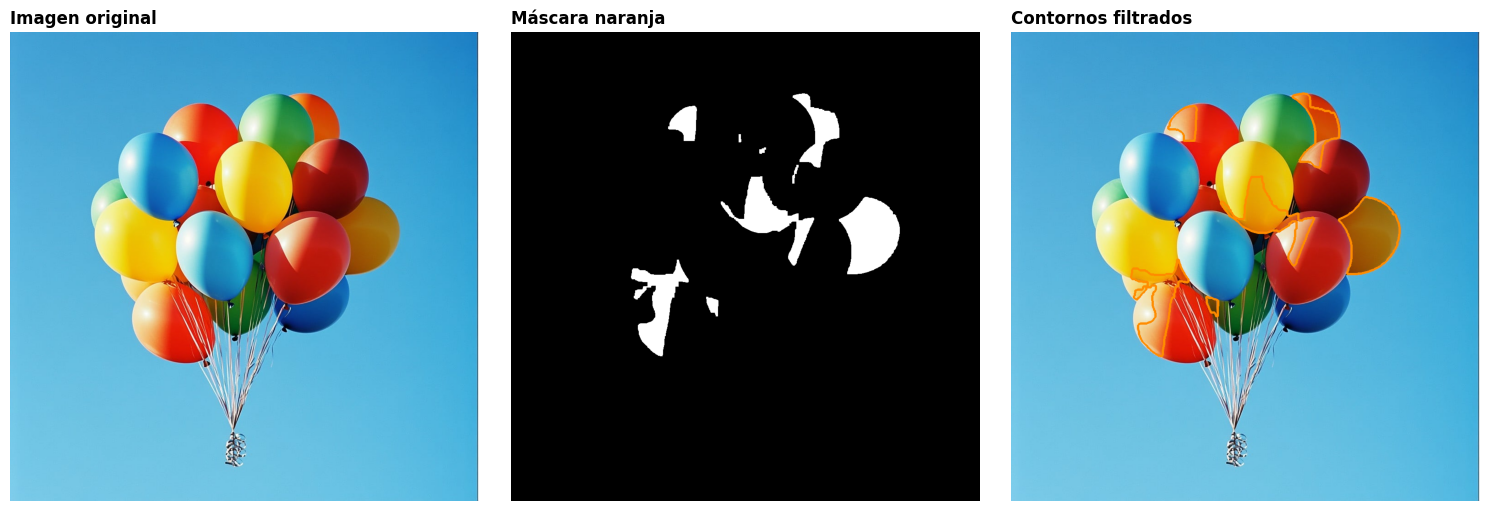

Contornos antes del filtrado: 9
Contornos conservados: 6


In [5]:
contornos_reales, _ = cv2.findContours(mascara_naranja.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contornos_filtrados = []
for contorno in contornos_reales:
    if cv2.contourArea(contorno) > 500:
        contornos_filtrados.append(contorno)

imagen_con_contornos = imagen_globos_rgb.copy()
cv2.drawContours(imagen_con_contornos, contornos_filtrados, -1, (255, 140, 0), 3)

fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
ejes[0].imshow(imagen_globos_rgb)
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_naranja, cmap="gray")
ejes[1].set_title("Máscara naranja", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(imagen_con_contornos)
ejes[2].set_title("Contornos filtrados", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()

print(f"Contornos antes del filtrado: {len(contornos_reales)}")
print(f"Contornos conservados: {len(contornos_filtrados)}")


Fijate que la calidad del contorno depende totalmente de la máscara. Si la segmentación deja ruido o se come partes del objeto, el contorno también queda mal. Por eso conviene pensar estas etapas como una cadena y no como funciones aisladas.


## Actividad breve

Modificá el rango de color o el criterio de área mínima y volvé a ejecutar el proceso. Después explicá:

1. qué cambió en la máscara;
2. qué cambió en los contornos detectados;
3. cuál sería un criterio razonable para decidir si un contorno vale la pena conservar.


## Cierre

Detectar contornos no es solo llamar a `findContours()`. Antes hace falta una máscara que represente bien el objeto de interés. Cuando esa etapa previa está bien resuelta, el contorno se vuelve una herramienta muy útil para medir, comparar y describir formas.
